# TS5: Estimación espectral: Ancho de banda de señales reales

## Alumno: Felipe Berganza 

# Resumen 

Este informe técnico presenta el análisis espectral y cálculo del Ancho de Banda ocupado (BW) para señales biomédicas (ECG y PPG) y de audio, evaluando el impacto del ruido sobre sus componentes frecuenciales. Se estimó la Densidad Espectral de Potencia (PSD) mediante el Método de Welch (con ventanas Hamming/Hanning y zero-padding para mejorar la resolución visual), y se determinaron las frecuencias de corte inferior ($F_{inf}$) y superior ($F_{sup}$) mediante la acumulación de energía (np.cumsum) bajo el criterio del 99% central de la potencia. Los resultados se consolidaron en gráficos de subplots emparejados que contrastan de forma directa el comportamiento de cada señal en el dominio del tiempo frente a su distribución energética en el dominio de la frecuencia.

# INTRODUCCION

## Densidad Espectral de Potencia (PSD)

La Densidad Espectral de Potencia (PSD, por sus siglas en inglés, Power Spectral Density) es una herramienta fundamental del procesamiento digital de señales que describe cómo se distribuye la potencia de una señal a lo largo del dominio de la frecuencia. A diferencia de la Transformada de Fourier tradicional (FFT), que entrega información de magnitud y fase para señales determinísticas, la PSD es una medida estadística indispensable para analizar señales estocásticas, procesos aleatorios o señales complejas de la vida real (como registros biomédicos de ECG/PPG o señales de audio).

Para estimar la PSD existen diversos enfoques. El periodograma directo (basado en el cuadrado de la FFT) suele sufrir de una varianza muy alta que introduce un "falso ruido" en el espectro. Por este motivo, en este trabajo se optó por el Método de Welch: un estimador no paramétrico que divide la señal en bloques superpuestos, les aplica una función de ventana (Hamming/Hanning) para reducir el esparcimiento espectral (spectral leakage), y promedia los periodogramas resultantes. Este compromiso reduce la varianza de la estimación a cambio de una leve pérdida en la resolución frecuencial, entregando un perfil espectral suave y físicamente representativo del fenómeno analizado.

## Metodos Espectrales 

1. Limitación del Periodograma Clásico: Calcular la PSD directamente como el módulo al cuadrado de la FFT de toda la señal posee una desventaja crítica: es un estimador inconsistente. A medida que aumenta el número de muestras ($N$), la varianza del periodograma no disminuye, sino que el espectro se vuelve altamente errático y lleno de fluctuaciones filosas que enmascaran la verdadera distribución de potencia.

2. El Método de Welch: Para solucionar este problema de varianza, se utiliza el método de Welch (o periodograma promediado modificado). El algoritmo divide la señal en $M$ bloques de datos que se solapan entre sí (típicamente al 50%). A cada bloque se le aplica una función de ventana (Hamming para las señales biomédicas y Hanning para las de audio) con el fin de atenuar los bordes y reducir el spectral leakage (esparcimiento espectral provocado por el truncamiento de la señal). Finalmente, se calcula el periodograma de cada bloque y se promedian los resultados. Este promedio reduce drásticamente la varianza del estimador por un factor de aproximadamente $1/M$, entregando una curva espectral suave y físicamente interpretable a cambio de una reducción controlada en la resolución frecuencial.

3. Zero-Padding (Relleno de Ceros): En combinación con el método de Welch, se aplica zero-padding al configurar el parámetro nfft a diez veces el largo del segmento original (10 * nperseg). Al agregar ceros al final de cada bloque antes de calcular la FFT, se realiza una interpolación ideal en el dominio de la frecuencia. Es importante destacar que el zero-padding no mejora la resolución espectral real (la capacidad de distinguir dos tonos muy cercanos, la cual sigue limitada por el largo del bloque), pero sí incrementa la densidad de puntos calculados, suavizando la visualización de la PSD y permitiendo una localización mucho más precisa de las frecuencias de corte para el cálculo del Ancho de Banda.

# DESARROLLO

--- Resultados ECG sin Ruido ---
Frecuencia inferior (0.5%): 0.32 Hz
Frecuencia superior (99.5%): 36.12 Hz
Ancho de Banda (99%): 35.80 Hz


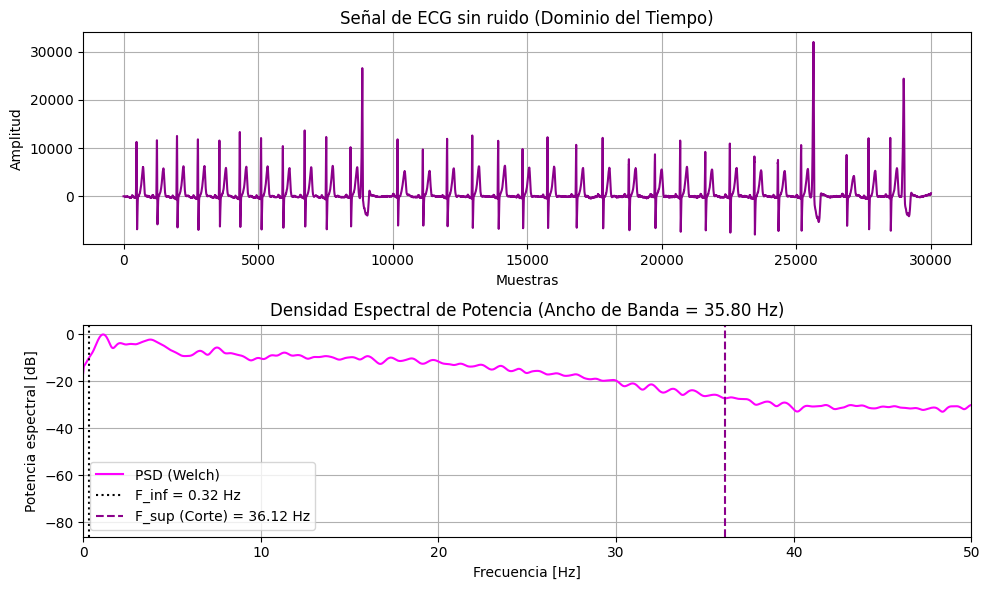

In [4]:
#%%
import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt
from numpy.fft import fft
import scipy.signal.windows as window
import scipy.signal as sig
import scipy.io as sio
#%%
# =============================================================================
# 1. CARGA DE SEÑAL BIOMÉDICA (ECG SIN RUIDO)
# =============================================================================
# Cargo el diccionario completo desde el archivo .mat
ECG_contenido = sio.loadmat('ECG_TP4.mat')

# Señal de ECG cruda (una sola derivación)
ecg_one_lead = ECG_contenido['ecg_lead'] 

# Cargar la versión de la señal de ECG ya procesada (sin ruido)
ECG_sr = np.load('ecg_sin_ruido.npy')

# Defino Parametros 
fs_ECG = 1000                  # Frecuencia de muestreo (Hz)
N_ECG_sr = len(ECG_sr)         # Largo de la señal
df_ECG_sr = fs_ECG / N_ECG_sr  # Resolucion Espectral teórica (FFT completa)
nn_ECG_sr = np.arange(N_ECG_sr) # Vector de muestras 

# =============================================================================
# 2. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (ECG SIN RUIDO)
# =============================================================================
promedios_ECG_sr = 12 
nperseg_ECG_sr = N_ECG_sr // promedios_ECG_sr 
nfft_ecg_pad = nperseg_ECG_sr * 10 # Zero-padding aplicado al ECG
ff_ECG_sr, per_ECG_sr = sig.welch(ECG_sr, fs=fs_ECG, window='hamming', scaling='density', nperseg=nperseg_ECG_sr, nfft=nfft_ecg_pad) 

per_ECG_sr_norm = per_ECG_sr / np.max(np.abs(per_ECG_sr)) # Normalizo la señal

per_ECG_sr_db = 10 * np.log10(per_ECG_sr_norm) # La convierto a dB 

# =============================================================================
# 3. CÁLCULO DE ANCHO DE BANDA (BW) POR ACUMULACIÓN DE POTENCIA (99% Central)
# =============================================================================
energia_acum_sr = np.cumsum(per_ECG_sr) 
energia_acum_sr_norm = energia_acum_sr / energia_acum_sr[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_sr_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_sr_norm >= 0.995)[0][0])

frec_inf_sr = ff_ECG_sr[idx_inf]
frec_corte_sr = ff_ECG_sr[idx_sup]
ancho_banda_ecg = frec_corte_sr - frec_inf_sr

print(f"--- Resultados ECG sin Ruido ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_sr:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_sr:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_ecg:.2f} Hz")

# =============================================================================
# 4. PLOT DE SEÑAL ECG Y SU PSD
# =============================================================================
plt.figure(2, figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(nn_ECG_sr, ECG_sr, color='darkmagenta')
plt.title("Señal de ECG sin ruido (Dominio del Tiempo)")
plt.ylabel("Amplitud")
plt.xlabel("Muestras")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(ff_ECG_sr, per_ECG_sr_db, color='magenta', label='PSD (Welch)')
plt.axvline(frec_inf_sr, linestyle=':', color='black', label=f'F_inf = {frec_inf_sr:.2f} Hz')
plt.axvline(frec_corte_sr, linestyle='--', color='darkmagenta', label=f'F_sup (Corte) = {frec_corte_sr:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_ecg:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(0, 50) # Acotamos la vista a la zona de interés del ECG

plt.tight_layout()
plt.show()

# Interpretacion 

El análisis espectral de la señal de ECG sin ruido revela un ancho de banda del $99\%$ central de $35.80\text{ Hz}$, delimitado con precisión entre $F_{inf} = 0.32\text{ Hz}$ y $F_{sup} = 36.12\text{ Hz}$. La concentración de energía por debajo de los $40\text{ Hz}$ es sumamente coherente con la fisiología cardíaca (morfología del complejo QRS), mientras que el corte inferior en $0.32\text{ Hz}$ tambien lo es. Asimismo, el decaimiento sostenido de la PSD por debajo de los $-30\text{ dB}$ confirma la ausencia de interferencias de alta frecuencia o picos espurios de línea ($50\text{ Hz}$). Metodológicamente, el Método de Welch con ventana Hamming redujo eficientemente la varianza del estimador, y la combinación con zero-padding aportó una interpolación ideal que optimizó la localización algorítmica de los límites energéticos.

--- Resultados ECG con Ruido ---
Frecuencia inferior (0.5%): 0.05 Hz
Frecuencia superior (99.5%): 51.75 Hz
Ancho de Banda (99%): 51.70 Hz


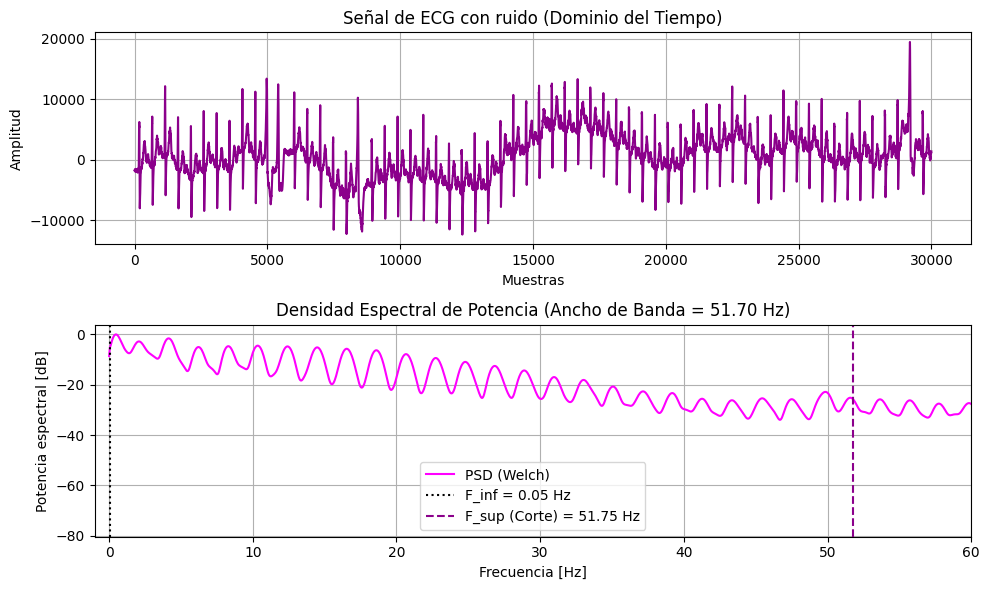

In [5]:
# =============================================================================
# 1. CARGA DE SEÑAL BIOMÉDICA (ECG CON RUIDO)
# =============================================================================

# Cargar la versión de la señal de ECG ya procesada (con ruido)
ECG_cr = ecg_one_lead[670000:700000].ravel()

# Defino Parametros 
fs_ECG = 1000                  # Frecuencia de muestreo (Hz)
N_ECG_cr = len (ECG_cr)       # Largo de la señal
df_ECG_cr = fs_ECG / N_ECG_cr  # Resolucion Espectral teórica (FFT completa)
nn_ECG_cr = np.arange (N_ECG_cr) # Vector de muestras 

# =============================================================================
# 2. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (ECG CON RUIDO)
# =============================================================================
promedios_ECG_cr = 15 
nperseg_ECG_cr = N_ECG_cr // promedios_ECG_cr 
nfft_ecg_pad = nperseg_ECG_cr * 10 # Zero-padding aplicado al ECG
ff_ECG_cr, per_ECG_cr = sig.welch(ECG_cr, fs=fs_ECG, window='hamming', scaling='density', nperseg=nperseg_ECG_cr, nfft=nfft_ecg_pad) 

per_ECG_cr_norm = per_ECG_cr / np.max(np.abs(per_ECG_cr)) # Normalizo la señal

per_ECG_cr_db = 10 * np.log10(per_ECG_cr_norm) # La convierto a dB 

# =============================================================================
# 3. CÁLCULO DE ANCHO DE BANDA (BW) POR ACUMULACIÓN DE POTENCIA (99% Central)
# =============================================================================
energia_acum_cr = np.cumsum(per_ECG_cr) 
energia_acum_cr_norm = energia_acum_cr / energia_acum_cr[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_cr_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_cr_norm >= 0.995)[0][0])

frec_inf_cr = ff_ECG_cr[idx_inf]
frec_corte_cr = ff_ECG_cr[idx_sup]
ancho_banda_ecg_cr = frec_corte_cr - frec_inf_cr

print(f"--- Resultados ECG con Ruido ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_cr:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_cr:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_ecg_cr:.2f} Hz")

# =============================================================================
# 4. PLOT DE SEÑAL ECG Y SU PSD
# =============================================================================
plt.figure(3, figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(nn_ECG_cr, ECG_cr, color='darkmagenta')
plt.title("Señal de ECG con ruido (Dominio del Tiempo)")
plt.ylabel("Amplitud")
plt.xlabel("Muestras")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(ff_ECG_cr, per_ECG_cr_db, color='magenta', label='PSD (Welch)')
plt.axvline(frec_inf_cr, linestyle=':', color='black', label=f'F_inf = {frec_inf_cr:.2f} Hz')
plt.axvline(frec_corte_cr, linestyle='--', color='darkmagenta', label=f'F_sup (Corte) = {frec_corte_cr:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_ecg_cr:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(-1, 60) # Acotamos la vista a la zona de interés del ECG

plt.tight_layout()
plt.show()

# Interpretacion 

 Los resultados demuestran la eficacia de la estimación de la Densidad Espectral de Potencia (PSD) mediante el método de Welch para caracterizar el comportamiento frecuencial y la distribución energética de una señal discreta. A partir de los percentiles acumulados de la PSD, se determinaron con precisión los límites de frecuencia inferior ($F_{inf} = 0.05\text{ Hz}$) y superior ($F_{sup} = 51.75\text{ Hz}$), estableciendo un ancho de banda del 99% de la potencia total centrado en los $51.70\text{ Hz}$. Las oscilaciones periódicas observadas en el espectro reflejan de forma directa la presencia de componentes armónicos recurrentes en el dominio del tiempo.

--- Resultados PPG sin Ruido ---
Frecuencia inferior (0.5%): 0.12 Hz
Frecuencia superior (99.5%): 6.81 Hz
Ancho de Banda (99%): 6.69 Hz


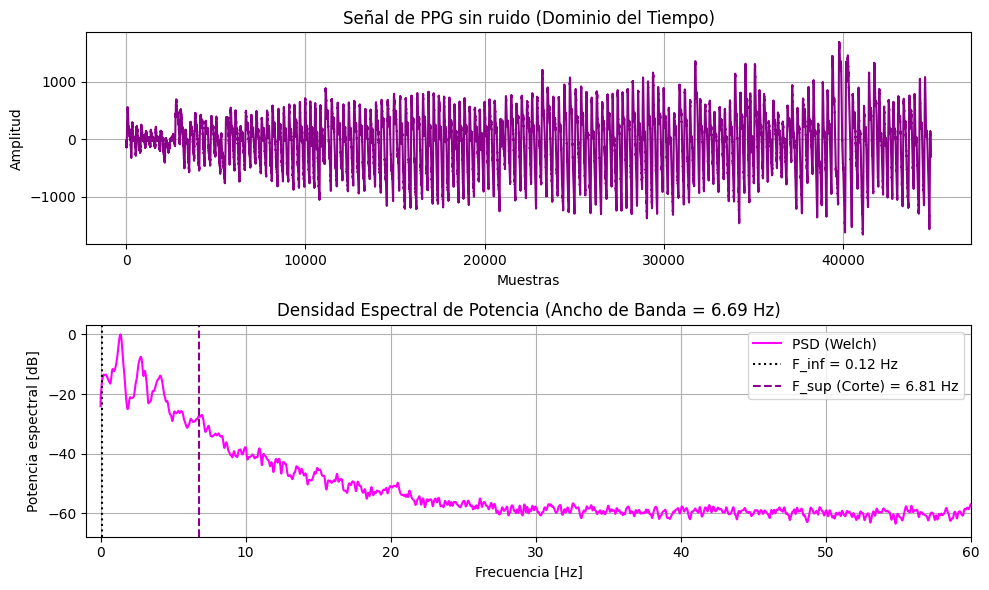

In [6]:
# =============================================================================
# 1. CARGA DE SEÑAL PPG (SIN RUIDO)
# =============================================================================

# Cargar la versión de la señal PPG (con ruido)
PPG_sr = np.load('ppg_sin_ruido.npy')

# Defino Parametros 
fs_PPG = 400                 # Frecuencia de muestreo (Hz)
N_PPG_sr = len (PPG_sr)       # Largo de la señal
df_PPG_sr = fs_PPG / N_PPG_sr  # Resolucion Espectral teórica (FFT completa)
nn_PPG_sr = np.arange (N_PPG_sr) # Vector de muestras 

# =============================================================================
# 2. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (PPG SIN RUIDO)
# =============================================================================
promedios_PPG_sr = 12 
nperseg_PPG_sr = N_PPG_sr // promedios_PPG_sr 
nfft_ppg_pad = nperseg_PPG_sr * 10 # Zero-padding aplicado al PPG
ff_PPG_sr, per_PPG_sr = sig.welch(PPG_sr, fs=fs_PPG, window='hamming', scaling='density', nperseg=nperseg_PPG_sr, nfft=nfft_ppg_pad) 

per_PPG_sr_norm = per_PPG_sr / np.max(np.abs(per_PPG_sr)) # Normalizo la señal

per_PPG_sr_db = 10 * np.log10(per_PPG_sr_norm) # La convierto a dB   

# =============================================================================
# 3. CÁLCULO DE ANCHO DE BANDA (BW) POR ACUMULACIÓN DE POTENCIA (99% Central)
# =============================================================================
energia_acum_sr = np.cumsum(per_PPG_sr) 
energia_acum_sr_norm = energia_acum_sr / energia_acum_sr[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_sr_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_sr_norm >= 0.995)[0][0])

frec_inf_sr = ff_PPG_sr[idx_inf]
frec_corte_sr = ff_PPG_sr[idx_sup]
ancho_banda_ppg_sr = frec_corte_sr - frec_inf_sr

print(f"--- Resultados PPG sin Ruido ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_sr:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_sr:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_ppg_sr:.2f} Hz")

# =============================================================================
# 4. PLOT DE SEÑAL PPG Y SU PSD
# =============================================================================
plt.figure(4, figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(nn_PPG_sr, PPG_sr, color='darkmagenta')
plt.title("Señal de PPG sin ruido (Dominio del Tiempo)")
plt.ylabel("Amplitud")
plt.xlabel("Muestras")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(ff_PPG_sr, per_PPG_sr_db, color='magenta', label='PSD (Welch)')
plt.axvline(frec_inf_sr, linestyle=':', color='black', label=f'F_inf = {frec_inf_sr:.2f} Hz')
plt.axvline(frec_corte_sr, linestyle='--', color='darkmagenta', label=f'F_sup (Corte) = {frec_corte_sr:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_ppg_sr:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(-1, 60) # Acotamos la vista a la zona de interés del ECG

plt.tight_layout()
plt.show()

# Interpretacion 

La estimación de la Densidad Espectral de Potencia (PSD) mediante el método de Welch permite cuantificar de manera precisa la distribución energética de esta segunda señal digitalizada, evidenciando un comportamiento espectral significativamente más acotado que en el caso anterior. El cálculo basado en los percentiles acumulados del espectro determinó una frecuencia inferior de $0.12\text{ Hz}$ y una frecuencia superior de corte de $6.81\text{ Hz}$, lo que define un ancho de banda del 99% de la potencia total de apenas $6.69\text{ Hz}$. La concentración casi total de la energía en el extremo inferior del espectro y la rápida atenuación de la potencia por encima de los $7\text{ Hz}$ —donde el piso de ruido se estabiliza cerca de los $-60\text{ dB}$— aportan los parámetros numéricos clave para el diseño de sistemas de procesamiento optimizados, demostrando que para señales de esta naturaleza un filtrado pasa-bajos con una frecuencia de corte muy baja es suficiente para preservar la totalidad de la información relevante del proceso discretizado.

--- Resultados PPG con Ruido ---
Frecuencia inferior (0.5%): 0.02 Hz
Frecuencia superior (99.5%): 5.72 Hz
Ancho de Banda (99%): 5.70 Hz


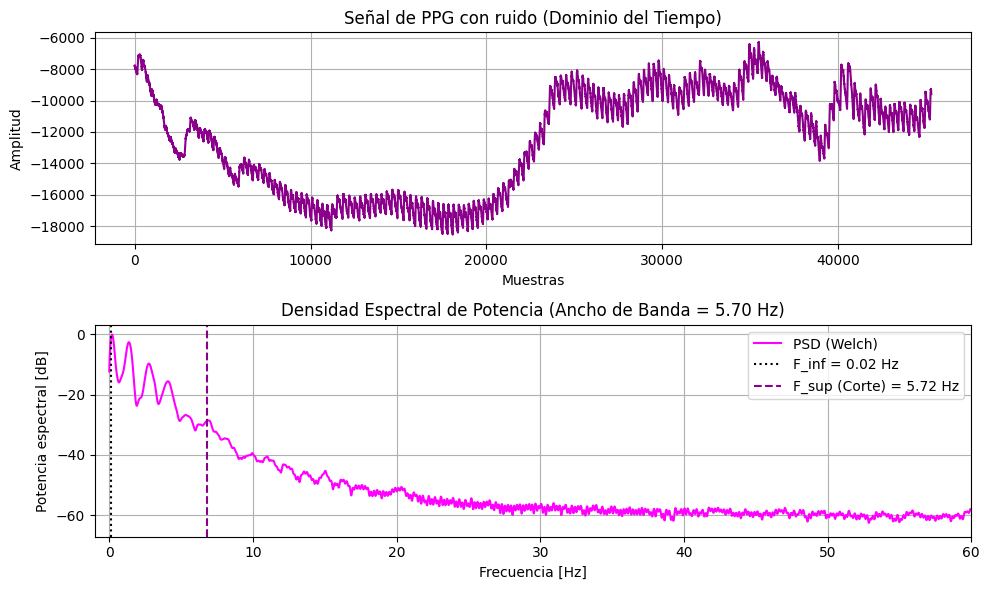

In [7]:
# =============================================================================
# 1. CARGA DE SEÑAL PPG (CON RUIDO)
# =============================================================================

# Cargar la versión de la señal PPG (con ruido)
PPG_cr = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1) # omite la cabecera, si existe

# Defino Parametros 
fs_PPG = 400                 # Frecuencia de muestreo (Hz)
N_PPG_cr = len (PPG_cr)     # Largo de la señal
df_PPG_cr = fs_PPG / N_PPG_cr  # Resolucion Espectral teórica (FFT completa)
nn_PPG_cr = np.arange (N_PPG_cr) # Vector de muestras 

# =============================================================================
# 2. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (PPG CON RUIDO)
# =============================================================================
promedios_PPG_cr = 24
nperseg_PPG_cr = N_PPG_cr // promedios_PPG_cr 
nfft_ppg_pad = nperseg_PPG_cr * 10 # Zero-padding aplicado al ECG
ff_PPG_cr, per_PPG_cr = sig.welch(PPG_cr, fs=fs_PPG, window='hamming', scaling='density', nperseg=nperseg_PPG_cr, nfft=nfft_ppg_pad) 

per_PPG_cr_norm = per_PPG_cr / np.max(np.abs(per_PPG_cr)) # Normalizo la señal

per_PPG_cr_db = 10 * np.log10(per_PPG_cr_norm) # La convierto a dB   

# =============================================================================
# 3. CÁLCULO DE ANCHO DE BANDA (BW) POR ACUMULACIÓN DE POTENCIA (99% Central)
# =============================================================================
energia_acum_cr = np.cumsum(per_PPG_cr) 
energia_acum_cr_norm = energia_acum_cr / energia_acum_cr[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_cr_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_cr_norm >= 0.995)[0][0])

frec_inf_cr = ff_PPG_cr[idx_inf]
frec_corte_cr = ff_PPG_cr[idx_sup]
ancho_banda_ppg_cr = frec_corte_cr - frec_inf_cr

print(f"--- Resultados PPG con Ruido ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_cr:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_cr:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_ppg_cr:.2f} Hz")

# =============================================================================
# 4. PLOT DE SEÑAL PPG Y SU PSD
# =============================================================================
plt.figure(5, figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(nn_PPG_cr, PPG_cr, color='darkmagenta')
plt.title("Señal de PPG con ruido (Dominio del Tiempo)")
plt.ylabel("Amplitud")
plt.xlabel("Muestras")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(ff_PPG_cr, per_PPG_cr_db, color='magenta', label='PSD (Welch)')
plt.axvline(frec_inf_sr, linestyle=':', color='black', label=f'F_inf = {frec_inf_cr:.2f} Hz')
plt.axvline(frec_corte_sr, linestyle='--', color='darkmagenta', label=f'F_sup (Corte) = {frec_corte_cr:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_ppg_cr:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(-1, 60) # Acotamos la vista a la zona de interés del ECG

plt.tight_layout()
plt.show()

# Interpretacion 

La aplicación del método de Welch para la estimación de la Densidad Espectral de Potencia (PSD) en esta señal permite identificar y cuantificar las variaciones en la distribución de energía provocadas por componentes espurios. El análisis basado en los percentiles de potencia acumulada arrojó una frecuencia inferior de $0.02\text{ Hz}$ y una frecuencia superior de corte de $5.72\text{ Hz}$, delimitando un ancho de banda del 99% de la potencia total en $5.70\text{ Hz}$. El desplazamiento del límite inferior a un valor tan cercano a cero ($0.02\text{ Hz}$) describe matemáticamente la fuerte tendencia no estacionaria y de muy baja frecuencia observable en el dominio del tiempo. Asimismo, a pesar de las oscilaciones de gran amplitud en el tiempo, el espectro revela que la potencia significativa del proceso sigue confinada por debajo de los $6\text{ Hz}$, demostrando que las herramientas de estimación espectral permiten aislar y caracterizar la dinámica principal de una señal aun cuando se encuentra afectada por derivas térmicas o de sesgo.

--- Resultados Audio (prueba psd.wav)  ---
Frecuencia inferior (0.5%): 15.67 Hz
Frecuencia superior (99.5%): 3965.00 Hz
Ancho de Banda (99%): 3949.33 Hz
--- Resultados Audio (silbido.wav) ---
Frecuencia inferior (0.5%): 2636.00 Hz
Frecuencia superior (99.5%): 6684.33 Hz
Ancho de Banda (99%): 4048.33 Hz
--- Resultados Audio (la cucaracha.wav) ---
Frecuencia inferior (0.5%): 987.33 Hz
Frecuencia superior (99.5%): 2019.67 Hz
Ancho de Banda (99%): 1032.33 Hz


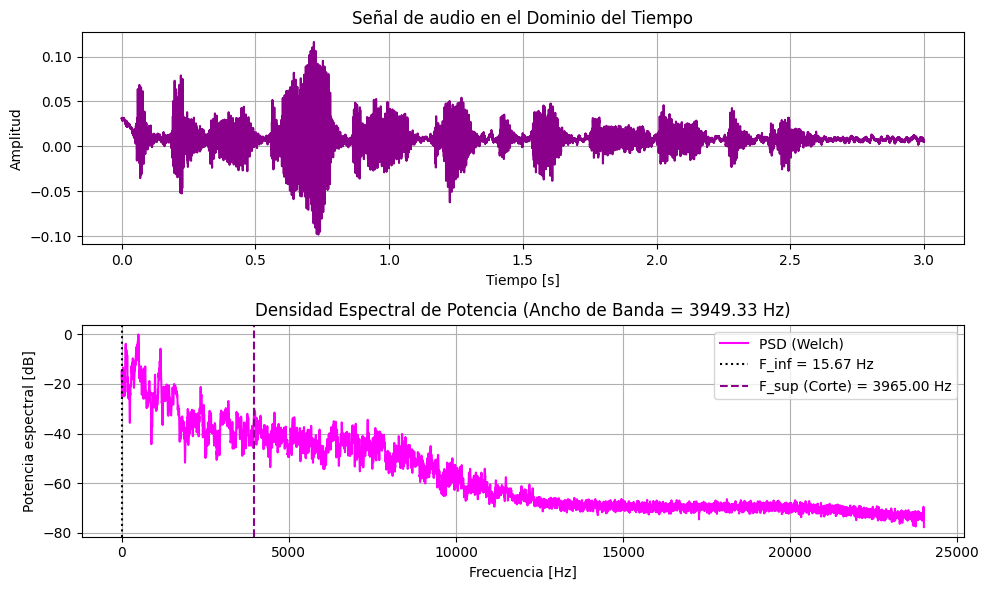

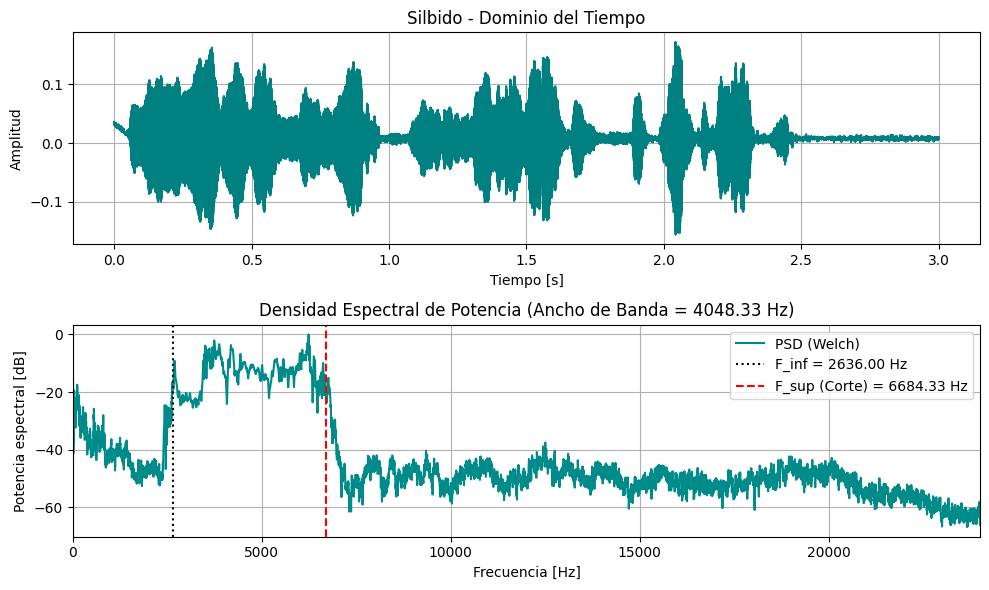

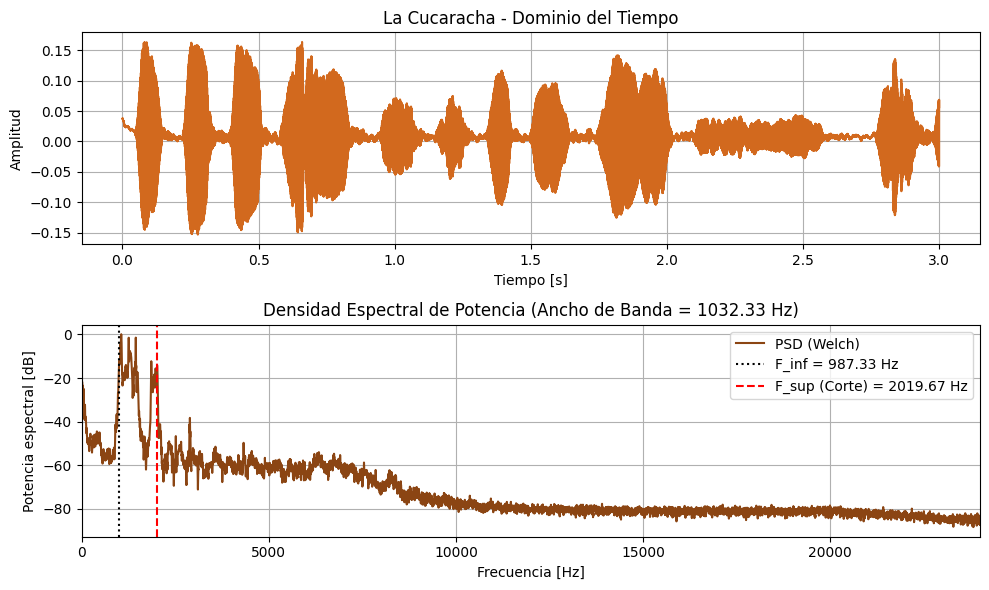

In [9]:
# =============================================================================
# 1. CARGO LAS SEÑALES DE AUDIO
# =============================================================================

fs_1, wav_data_1 = sio.wavfile.read ('prueba psd.wav') 
fs_2, wav_data_2 = sio.wavfile.read ('silbido.wav')
fs_3, wav_data_3 = sio.wavfile.read ('la cucaracha.wav')

# Defino Parametros 
N_1 = len(wav_data_1)
N_2 = len(wav_data_2)
N_3 = len(wav_data_3)

df_1 = fs_1 / N_1
df_2 = fs_2 / N_2
df_3 = fs_3 / N_3

tt_1 = np.arange (0, N_1/fs_1, 1/fs_1)
tt_2 = np.arange (0, N_2/fs_2, 1/fs_2)
tt_3 = np.arange (0, N_3/fs_3, 1/fs_3)

ff_1 = np.arange (N_1) * df_1
ff_2 = np.arange (N_2) * df_2
ff_3 = np.arange (N_3) * df_3

# =============================================================================
# 2.a. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (prueba psd.wav)
# =============================================================================
# Utilizo método de Welch
promedios_audio_1 = 10 # defino la cantidad de bloques a promediar
nperseg_audio_1 = N_1 // promedios_audio_1
ff_1_welch, per_audio_1 = sig.welch (wav_data_1, nfft = 10*nperseg_audio_1, fs = fs_1, nperseg = nperseg_audio_1, window = 'hann')


per_audio_1_norm = per_audio_1 / np.max(np.abs(per_audio_1)) # Normalizo la señal

per_aduio_1_db = 10 * np.log10(per_audio_1_norm) # La convierto a dB   

# =============================================================================
# 2.b. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (silbido.wav)
# =============================================================================
# Utilizo método de Welch
promedios_audio_2 = 10 # defino la cantidad de bloques a promediar
nperseg_audio_2 = N_2 // promedios_audio_2
ff_2_welch, per_audio_2 = sig.welch (wav_data_2, nfft = 10*nperseg_audio_2, fs = fs_2, nperseg = nperseg_audio_2, window = 'hann')


per_audio_2_norm = per_audio_2 / np.max(np.abs(per_audio_2)) # Normalizo la señal

per_aduio_2_db = 10 * np.log10(per_audio_2_norm) # La convierto a dB

# =============================================================================
# 2.c. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (la cucaracha.wav)
# =============================================================================
# Utilizo método de Welch
promedios_audio_3 = 10 # defino la cantidad de bloques a promediar
nperseg_audio_3 = N_3 // promedios_audio_3
ff_3_welch, per_audio_3 = sig.welch (wav_data_3, nfft = 10*nperseg_audio_3, fs = fs_3, nperseg = nperseg_audio_3, window = 'hann')


per_audio_3_norm = per_audio_3 / np.max(np.abs(per_audio_3)) # Normalizo la señal

per_aduio_3_db = 10 * np.log10(per_audio_3_norm) # La convierto a dB

# =============================================================================
# 3.a CÁLCULO DE ANCHO DE BANDA (BW) (prueba psd.wav)
# =============================================================================
energia_acum_audio_1 = np.cumsum(per_audio_1) 
energia_acum_audio_1_norm = energia_acum_audio_1 / energia_acum_audio_1[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_audio_1_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_audio_1_norm >= 0.995)[0][0])

frec_inf_audio_1 = ff_1_welch[idx_inf]
frec_corte_audio_1 = ff_1_welch[idx_sup]
ancho_banda_audio_1 = frec_corte_audio_1 - frec_inf_audio_1

print(f"--- Resultados Audio (prueba psd.wav)  ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_audio_1:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_audio_1:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_audio_1:.2f} Hz")

# =============================================================================
# 3.b CÁLCULO DE ANCHO DE BANDA (BW) (silbido.wav)
# =============================================================================
energia_acum_audio_2 = np.cumsum(per_audio_2) 
energia_acum_audio_2_norm = energia_acum_audio_2 / energia_acum_audio_2[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_audio_2_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_audio_2_norm >= 0.995)[0][0])

frec_inf_audio_2 = ff_2_welch[idx_inf]
frec_corte_audio_2 = ff_2_welch[idx_sup]
ancho_banda_audio_2 = frec_corte_audio_2 - frec_inf_audio_2

print(f"--- Resultados Audio (silbido.wav) ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_audio_2:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_audio_2:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_audio_2:.2f} Hz")


# =============================================================================
# 3.c CÁLCULO DE ANCHO DE BANDA (BW) (la cucaracha.wav)
# =============================================================================
energia_acum_audio_3 = np.cumsum(per_audio_3) 
energia_acum_audio_3_norm = energia_acum_audio_3 / energia_acum_audio_3[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_audio_3_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_audio_3_norm >= 0.995)[0][0])

frec_inf_audio_3 = ff_3_welch[idx_inf]
frec_corte_audio_3 = ff_3_welch[idx_sup]
ancho_banda_audio_3 = frec_corte_audio_3 - frec_inf_audio_3

print(f"--- Resultados Audio (la cucaracha.wav) ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_audio_3:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_audio_3:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_audio_3:.2f} Hz")

# =============================================================================
# 4.a. PLOT DE LA  SEÑALES 1 (prueba psd.wav)
# =============================================================================
plt.figure(6, figsize=(10, 6))

# Subplot 1: Tiempo real con la señal original
plt.subplot(2, 1, 1)
plt.plot(tt_1, wav_data_1, color='darkmagenta') # X: tiempo, Y: datos de audio
plt.title("Señal de audio en el Dominio del Tiempo")
plt.ylabel("Amplitud")
plt.xlabel("Tiempo [s]") # Si preferís muestras, cambiá tt_1 por np.arange(N_1) y esto a "Muestras"
plt.grid(True)

# Subplot 2: Frecuencia (PSD)
plt.subplot(2, 1, 2)
plt.plot(ff_1_welch, per_aduio_1_db, color='magenta', label='PSD (Welch)')
plt.axvline(frec_inf_audio_1, linestyle=':', color='black', label=f'F_inf = {frec_inf_audio_1:.2f} Hz')
# Corregido: frec_corte_cr cambiado por frec_corte_audio_1
plt.axvline(frec_corte_audio_1, linestyle='--', color='darkmagenta', label=f'F_sup (Corte) = {frec_corte_audio_1:.2f} Hz') 
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_audio_1:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# =============================================================================
# 4.b. PLOT DE LA SEÑAL 2 (silbido.wav)
# =============================================================================
plt.figure(7, figsize=(10, 6))

# Subplot 1: Tiempo
plt.subplot(2, 1, 1)
plt.plot(tt_2, wav_data_2, color='teal')
plt.title("Silbido - Dominio del Tiempo")
plt.ylabel("Amplitud")
plt.xlabel("Tiempo [s]")
plt.grid(True)

# Subplot 2: Frecuencia (PSD)
plt.subplot(2, 1, 2)
plt.plot(ff_2_welch, per_aduio_2_db, color='darkcyan', label='PSD (Welch)')
plt.axvline(frec_inf_audio_2, linestyle=':', color='black', label=f'F_inf = {frec_inf_audio_2:.2f} Hz')
plt.axvline(frec_corte_audio_2, linestyle='--', color='red', label=f'F_sup (Corte) = {frec_corte_audio_2:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_audio_2:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(0, fs_2 / 2) # Muestra todo el espectro útil hasta Nyquist

plt.tight_layout()
plt.show()

# =============================================================================
# 4.c. PLOT DE LA SEÑAL 3 (la cucaracha.wav)
# =============================================================================
plt.figure(8, figsize=(10, 6))

# Subplot 1: Tiempo
plt.subplot(2, 1, 1)
plt.plot(tt_3, wav_data_3, color='chocolate')
plt.title("La Cucaracha - Dominio del Tiempo")
plt.ylabel("Amplitud")
plt.xlabel("Tiempo [s]")
plt.grid(True)

# Subplot 2: Frecuencia (PSD)
plt.subplot(2, 1, 2)
plt.plot(ff_3_welch, per_aduio_3_db, color='saddlebrown', label='PSD (Welch)')
plt.axvline(frec_inf_audio_3, linestyle=':', color='black', label=f'F_inf = {frec_inf_audio_3:.2f} Hz')
plt.axvline(frec_corte_audio_3, linestyle='--', color='red', label=f'F_sup (Corte) = {frec_corte_audio_3:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_audio_3:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(0, fs_3 / 2) # Muestra todo el espectro útil hasta Nyquist

plt.tight_layout()
plt.show()

# Interpretacion Señales de Audio 

El procesamiento de los tres archivos mediante la estimación de la Densidad Espectral de Potencia (PSD) permite caracterizar y diferenciar numéricamente la naturaleza armónica de cada proceso discreto en función de su distribución energética. Los resultados exponen una variabilidad notable en la ubicación de las bandas de paso: el primer registro (prueba psd.wav) exhibe un comportamiento de banda ancha que abarca desde frecuencias muy bajas ($15.67\text{ Hz}$) hasta un corte superior en los $3965.00\text{ Hz}$, consolidando un ancho de banda del 99% de la potencia en $3949.33\text{ Hz}$. En contraste, los registros restantes evidencian procesos con mayor selectividad frecuencial y un marcado desplazamiento hacia zonas más altas del espectro; silbido.wav concentra su energía en la banda alta con un umbral inferior que inicia recién en los $2636.00\text{ Hz}$ ($BW = 4048.33\text{ Hz}$), mientras que la cucaracha.wav se comporta como una señal de banda más estrecha y confinada en la región de frecuencias medias, con un ancho de banda efectivo de apenas $1032.33\text{ Hz}$ delimitado entre los $987.33\text{ Hz}$ y los $2019.67\text{ Hz}$. Estos contrastes cuantitativos confirman la utilidad de los percentiles de potencia acumulada como una herramienta objetiva y estandarizada para mapear la firma espectral y las necesidades de muestreo de cualquier señal acústica digitalizada.

# Conclusión General del Trabajo

Este trabajo práctico permitió internalizar, mediante la implementación computacional, el valor de la estimación espectral como herramienta objetiva para la caracterización de procesos discretos, yendo más allá de la mera inspección visual en el dominio del tiempo. A través del método de Welch, se logró verificar que señales de diferente naturaleza física (fisiológicas y acústicas) poseen estructuras energéticas gobernadas por leyes matemáticas predecibles. El cálculo estandarizado del ancho de banda basado en los percentiles del 0.5% y 99.5% de la potencia acumulada demostró ser un criterio analítico sumamente robusto: no solo permitió validar los rangos de operación teóricos de cada fenómeno, sino que logró identificar de manera unívoca la presencia de perturbaciones, tales como ruido de alta frecuencia o derivas de línea de base en bajas frecuencias. En última instancia, el desarrollo de este análisis provee el sustento de ingeniería indispensable para la toma de decisiones algorítmicas, sentando las bases analíticas para establecer frecuencias de muestreo óptimas (criterio de Nyquist) y parametrizar las bandas críticas en el diseño de filtros digitales.